# ODE symmetry detection examples

The purpose of this notebook is to explore the algebra of reconstructed symmetries for a series of ODE examples.

Workflow:
1. Trajectory generation, from the standard examples.
2. "BASIS_TYPE", "PARAM_RANGE" and "PARAM_LIST" can be changed and re-run to 
explore different basis.
3. SV_CHOICE allows the user to select a set of coefficents from the null space.

## 1. Trajectory generation

Select the ODE example you would like to test. Uses the package-wide defaults for the chosen ODE (via `resolve_ode_args`) —
not tunable here by design; only `ODE` above affects this.

ODE = 'bernoulli'


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 500 initial conditions     │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-12, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


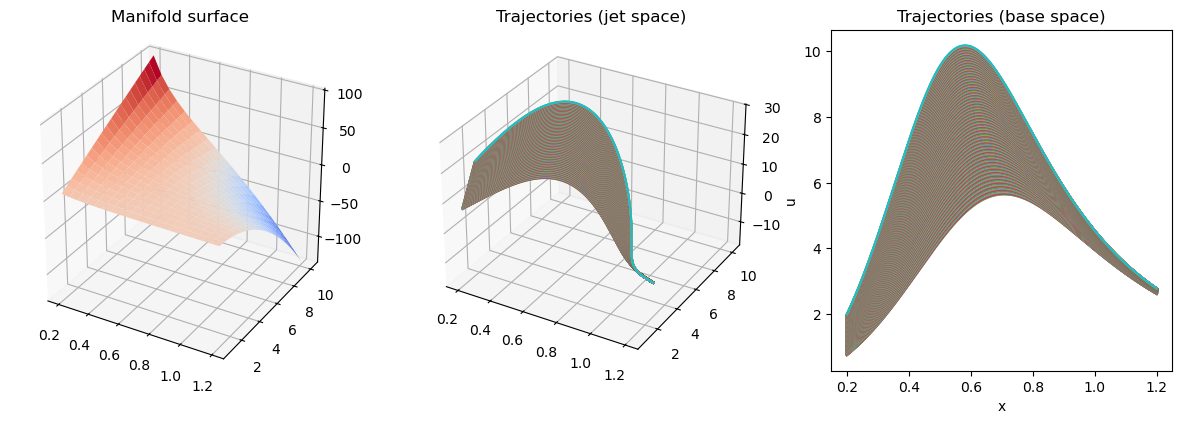

In [ ]:
import argparse

import numpy as np
from matplotlib import pyplot as plt

from symmetry_detection import data_matrices as dm
from symmetry_detection import generate_trajectories as gtr
from symmetry_detection import manifold as mfd
from symmetry_detection import plotting as plot
from symmetry_detection import reporting as rpt
from symmetry_detection import solver

%matplotlib inline

# --- ODE choice ---
# One of gtr.ODES.keys(): "bernoulli", "rational", "riccati", "scaling", "abel"
ODE = "bernoulli"
analytic_derivative = False
num_points = 3000
initial_conditions = np.linspace(0.75, 2, 500)
rtol = 1e-12
atol = 1e-12

# --- Normal field: analytic (exact, from the known ODE) vs. data-driven
# (mfd.estimate_normal_field, a 2D/scattered-data generalization of
# Savitzky-Golay - see "## 2. Normal field computation" below and
# manifold.py for why this needs multiple trajectories, not just one).
# normal_window=(di, dj), normal_degree, normal_boundary_margin only matter
# when analytic_normal=False.
analytic_normal = True
normal_window = (2, 5)
normal_degree = 1
normal_boundary_margin = 0  # extra trajectories/points to discard beyond window/di,dj

# --- Optional subsampling (only matters when analytic_normal=False): use ALL
# of X (many trajectories/points, however dense num_points/initial_conditions
# above are) to fit a good normal field, but feed only a smaller, evenly
# spaced subset into the symmetry-detection linear algebra below via
# mfd.subsample_trajectories - solve_svd/G_matrix work well, and stay cheap,
# with relatively few trajectories/points; it's only the normal-field
# estimation itself that benefits from density.
subsample_normal_field = True
subsample_num_traj = 10    # e.g. 6 - None keeps all (post-boundary-discard) trajectories
subsample_num_points = 100   # e.g. 100 - None keeps all points

print(f"ODE = {ODE!r}")

# Reuse the same resolution function the CLI/example scripts use, so this
# notebook can never disagree with them about what "default" means. Note this
# also resolves rtol/atol (defaults.DEFAULT_RTOL/DEFAULT_ATOL): those matter a
# lot more than num_points for how well the numerical derivative embedding
# (analytic_derivative=False) can agree with the analytic one - see the next
# cell.
ode_args = argparse.Namespace(
    ode=ODE, start=None, end=None, initial_conditions=None, num_points=None, method=None,
    rtol=None, atol=None,
)
ode_args = gtr.resolve_ode_args(ode_args)

X = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=rtol,
    atol=atol,
    analytic_derivative=analytic_derivative
)
X_stacked = gtr.concatenate_trajectories(X)

# Plot the generated trajectories
# Grid of values of the surface manifold over [x_min, x_max] x [u_min, u_max]
x_min, x_max = np.min(X[:, 0, :]), np.max(X[:, 0, :])
u_min, u_max = np.min(X[:, 1, :]), np.max(X[:, 1, :])

res = 20
X_grid = np.linspace(x_min, x_max, res)
U_grid = np.linspace(u_min, u_max, res)
X_grid, U_grid = np.meshgrid(X_grid, U_grid)
P_grid = gtr.ODES[ode_args.ode](X_grid, U_grid)
p_grid_min, p_grid_max = np.min(P_grid), np.max(P_grid)

# Manifold surface, jet-space trajectories, and (x, u) trajectories side by side
manifold_fig = plt.figure(figsize=(12, 4))
ax0 = manifold_fig.add_subplot(131, projection='3d')
ax1 = manifold_fig.add_subplot(132, projection='3d')
ax2 = manifold_fig.add_subplot(133)

ax0.set_aspect('equal')
ax2.set_box_aspect(1)

ax0.plot_surface(X_grid, U_grid, P_grid, cmap='coolwarm')
ax0.set_title("Manifold surface")

for trajectory in X:
    ax1.plot(trajectory[0, :], trajectory[1, :], trajectory[2, :])
    ax2.plot(trajectory[0, :], trajectory[1, :])

ax1.set_title("Trajectories (jet space)")
ax2.set_title("Trajectories (base space)")
ax2.set_xlabel("x")
ax2.set_ylabel("u")

manifold_fig.tight_layout()

### Analytic vs. numerical derivative comparison

Sanity check, independent of the `analytic_derivative` flag chosen above: generate the jet-space
embedding once with the analytic derivative (blue) and once with the numerical (Savitzky-Golay)
derivative (red), and compare two orthogonal projections of the 3D trajectories: `u_x` vs `u`,
and `u_x` vs `x`.

          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 400 points/trajectory      │
│ Trajectory Count │ 100 initial conditions     │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 400 points/trajectory      │
│ Trajectory Count │ 100 initial conditions     │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative
max |u_x_numeric - u_x_analytic| = 6.109e-04


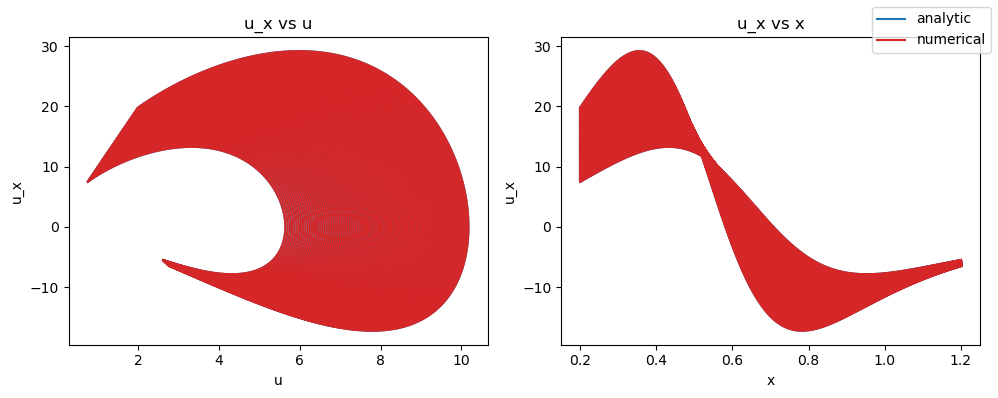

In [10]:
X_analytic = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=ode_args.rtol,
    atol=ode_args.atol,
    analytic_derivative=True
)
X_numeric = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=ode_args.rtol,
    atol=ode_args.atol,
    analytic_derivative=False
)

print(f"max |u_x_numeric - u_x_analytic| = {np.max(np.abs(X_analytic[:, 2, :] - X_numeric[:, 2, :])):.3e}")

deriv_fig, (ax_u, ax_x) = plt.subplots(1, 2, figsize=(10, 4))

for trajectory in X_analytic:
    ax_u.plot(trajectory[1, :], trajectory[2, :], color="tab:blue", label="analytic")
    ax_x.plot(trajectory[0, :], trajectory[2, :], color="tab:blue", label="analytic")

for trajectory in X_numeric:
    ax_u.plot(trajectory[1, :], trajectory[2, :], color="tab:red", label="numerical")
    ax_x.plot(trajectory[0, :], trajectory[2, :], color="tab:red", label="numerical")

ax_u.set_xlabel("u")
ax_u.set_ylabel("u_x")
ax_u.set_title("u_x vs u")

ax_x.set_xlabel("x")
ax_x.set_ylabel("u_x")
ax_x.set_title("u_x vs x")

handles, labels = ax_u.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
deriv_fig.legend(by_label.values(), by_label.keys(), loc="upper right")

deriv_fig.tight_layout()

### Why the SV-spectrum drop can disappear with the numerical embedding

With `analytic_derivative=True`, `N` (the analytic gradient of the manifold `F = u_x - f(x,u)`,
depending only on `x, u`) and the third jet coordinate `u_x = f(x,u)` used to build `P` are
computed from the *same* exact formula, so the trajectory sits exactly on the manifold and the
symmetry condition `xi*N_x + eta*N_u + N_ux*zeta = 0` is satisfied to machine precision by the
true generator.

With `analytic_derivative=False`, `N` is still the *exact* analytic gradient (it never depends on
`u_x` at all — look at `grad_rational_ode` etc. in `generate_trajectories.py`), but `P` is now the
Savitzky–Golay estimate of `u_x`, which differs from `f(x,u)` by the derivative-estimation error.
That difference feeds linearly into `G` (via the `P` terms in `data_matrices.G_matrix`), so the
points are effectively evaluated slightly *off* the manifold. The true generator no longer lies
exactly in the null space of `G` — its residual is roughly proportional to the derivative error —
which is exactly why the smallest singular value stops being many orders of magnitude below the
rest, even though it still points in roughly the right direction.

The open question was: this residual should shrink, and the drop should sharpen, as `num_points`
grows — but it doesn't. The cell below sweeps `num_points` at two `solve_ivp` tolerance settings
and plots both the raw derivative error and the sharpness of the SV drop. The answer turns out to
have nothing to do with the differentiation scheme or the normal field: `t_eval` (i.e.
`num_points`) only controls how densely the *already-integrated* adaptive-step solution is
resampled — it does not make the integration itself any more accurate. `solve_ivp`'s own defaults
(`rtol=1e-3, atol=1e-6`) leave the trajectory with a fixed ~1e-3 relative defect no matter how many
points you sample it at, and that defect dominates the derivative error at essentially any
`num_points`. Tightening `rtol`/`atol` (see `defaults.DEFAULT_RTOL`/`DEFAULT_ATOL`, now used by
`resolve_ode_args` above) removes that floor and restores convergence.

          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 30 points/trajectory       │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 30 points/trajectory       │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 100 points/trajectory      │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

...

          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-03, atol=1.0e-06 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-03, atol=1.0e-06 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


If the derivative error plateaus instead of shrinking with num_points, the bottleneck
is solve_ivp's tolerance, not the differentiation scheme or the normal field: t_eval
only resamples the already-computed adaptive-step solution, it does not refine it.


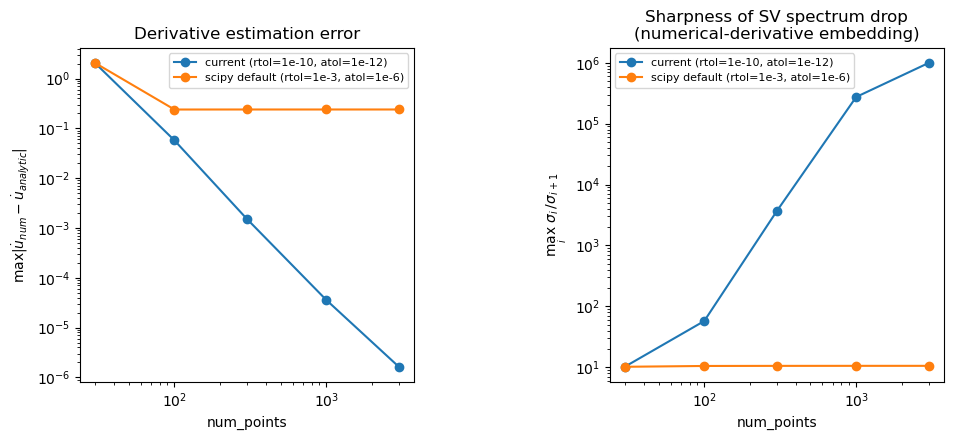

In [3]:
# Sweep num_points at two solve_ivp tolerance settings and track:
#   1. the raw derivative-estimation error (numeric vs analytic embedding), and
#   2. the sharpness of the SV spectrum drop (max adjacent ratio S[i]/S[i+1])
#      for the numerical-derivative embedding, using a fixed small monomial
#      basis (independent of BASIS_TYPE/PARAM_RANGE chosen further below).
sweep_num_points = [30, 100, 300, 1000, 3000]
tolerance_settings = {
    f"current (rtol={ode_args.rtol:.0e}, atol={ode_args.atol:.0e})": (ode_args.rtol, ode_args.atol),
    "scipy default (rtol=1e-3, atol=1e-6)": (1e-3, 1e-6),
}

convergence = {}
for label, (sweep_rtol, sweep_atol) in tolerance_settings.items():
    max_errs, gap_ratios = [], []
    for n in sweep_num_points:
        X_an_n = gtr.generate_equation_manifold(
            ode_name=ode_args.ode, x_start=ode_args.start, x_end=ode_args.end,
            initial_conditions=ode_args.initial_conditions, num_points=n,
            method=ode_args.method, rtol=sweep_rtol, atol=sweep_atol, analytic_derivative=True,
        )
        X_num_n = gtr.generate_equation_manifold(
            ode_name=ode_args.ode, x_start=ode_args.start, x_end=ode_args.end,
            initial_conditions=ode_args.initial_conditions, num_points=n,
            method=ode_args.method, rtol=sweep_rtol, atol=sweep_atol, analytic_derivative=False,
        )
        max_errs.append(np.max(np.abs(X_an_n[:, 2, :] - X_num_n[:, 2, :])))

        X_stacked_n = gtr.concatenate_trajectories(X_num_n)
        N_n = gtr.NORMALS[ode_args.ode](X_stacked_n[0], X_stacked_n[1])
        svd_n = solver.solve_svd(X_stacked_n, N_n, basis_type="monomial", param_range=(0, 1), characteristic=False)
        Sn = svd_n.S / svd_n.S[0]
        gap_ratios.append(np.max(Sn[:-1] / Sn[1:]))

    convergence[label] = (np.array(max_errs), np.array(gap_ratios))

conv_fig, (ax_err, ax_gap) = plt.subplots(1, 2, figsize=(11, 4.5))
for label, (max_errs, gap_ratios) in convergence.items():
    ax_err.loglog(sweep_num_points, max_errs, marker='o', label=label)
    ax_gap.loglog(sweep_num_points, gap_ratios, marker='o', label=label)

ax_err.set_xlabel("num_points")
ax_err.set_ylabel(r"$\max|\dot u_{num} - \dot u_{analytic}|$")
ax_err.set_title("Derivative estimation error")
ax_err.legend(fontsize=8)
ax_err.set_box_aspect(1)

ax_gap.set_xlabel("num_points")
ax_gap.set_ylabel(r"$\max_i\ \sigma_i/\sigma_{i+1}$")
ax_gap.set_title("Sharpness of SV spectrum drop\n(numerical-derivative embedding)")
ax_gap.legend(fontsize=8)
ax_gap.set_box_aspect(1)

conv_fig.tight_layout()

print("If the derivative error plateaus instead of shrinking with num_points, the bottleneck")
print("is solve_ivp's tolerance, not the differentiation scheme or the normal field: t_eval")
print("only resamples the already-computed adaptive-step solution, it does not refine it.")

## 2. Normal field computation.

Toggle `analytic_normal` above to choose between:

- **`True`**: the exact normal field `N = (-f_x, -f_u, 1)`, differentiated analytically from the
  known right-hand side `f(x, u)` (`gtr.NORMALS[ode_args.ode]`).
- **`False`**: `mfd.estimate_normal_field`, a purely data-driven estimate of `N` from the
  multi-trajectory point cloud alone (no knowledge of `f`). A single trajectory only samples the
  curve `u(x)`; differentiating `u_x` along it gives one equation (`u_xx = f_x + u_x f_u`) in the
  two unknowns `f_x, f_u`, so recovering them separately needs variation in `u` at (approximately)
  fixed `x` — i.e. neighboring trajectories, not just further points along the same one. Because
  every trajectory shares the same `x` grid, neighborhoods in `(x, u)` can be built by plain
  index-slicing in `(trajectory, point)` space, with no nearest-neighbor search — see `manifold.py`
  for details.

  The trajectories/points at the edge of this index window only get one-sided, structurally less
  reliable gradient estimates, so `normal_window=(di, dj)` worth of them are always discarded;
  `normal_boundary_margin` optionally discards *additional* trajectories/points beyond that
  minimum (e.g. to use a wide window for a good fit while only trusting/reporting a smaller core
  region). Independently, `subsample_normal_field` lets you fit the normal field from a *dense*
  point cloud (many trajectories/points — density is what `estimate_normal_field` needs to
  separate `f_x` from `f_u`) but feed a much smaller, evenly-spaced subset into the
  symmetry-detection SVD below (`mfd.subsample_trajectories`) — the SVD/`G_matrix` step works well,
  and stays cheap, with relatively few points; it's only the normal-field estimation that benefits
  from density.

  **This cell overwrites `X_stacked` with the resulting (cropped and/or subsampled) subset** when
  `analytic_normal=False`, so everything downstream (SVD, plots) only ever sees points that stay
  column-aligned with `N`.

estimate_normal_field: kept 496/500 trajectories and 2990/3000 points/trajectory after discarding the boundary (window=(2, 5), degree=1, boundary_margin=0, max local-fit condition number=3.42e+04).
subsample_trajectories: kept 10 trajectories and 100 points/trajectory for symmetry detection (1483040 -> 1000 points fed into G_matrix/solve_svd; the dense estimate above is still what the normal field itself was fit from).
X_stacked has been overwritten with this (cropped/subsampled) subset so it stays column-aligned with N for everything downstream.
(3, 1000)


Text(0.5, 0.92, 'Numeric (data-driven) normal field')

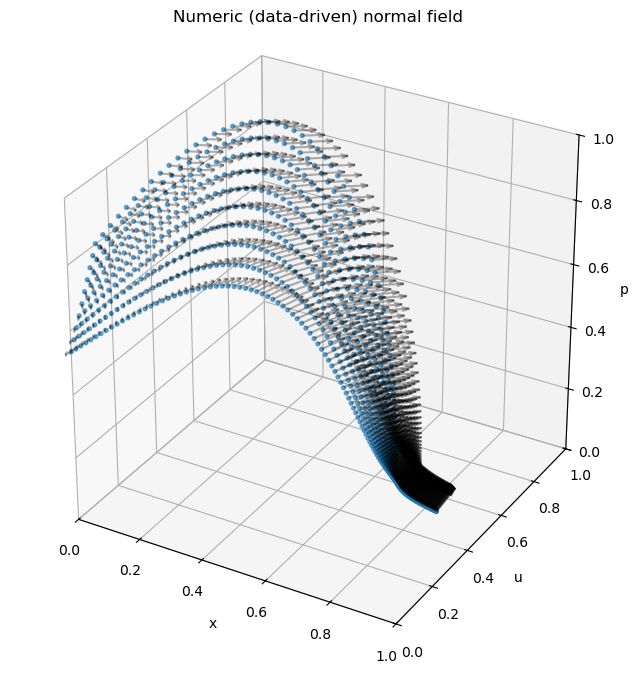

In [9]:
# Always start from the full, untrimmed X so this cell is safe to re-run
# (e.g. after flipping analytic_normal) without re-running cell 2.
X_stacked = gtr.concatenate_trajectories(X)

if analytic_normal:
    N = gtr.NORMALS[ode_args.ode](X_stacked[0], X_stacked[1])
else:
    normal_est = mfd.estimate_normal_field(
        X, window=normal_window, degree=normal_degree,
        discard_boundary=True, boundary_margin=normal_boundary_margin,
    )
    X_dense, N_dense = normal_est.apply(X), normal_est.N
    print(
        f"estimate_normal_field: kept {N_dense.shape[1]}/{X.shape[0]} trajectories and "
        f"{N_dense.shape[2]}/{X.shape[2]} points/trajectory after discarding the boundary "
        f"(window={normal_window}, degree={normal_degree}, "
        f"boundary_margin={normal_boundary_margin}, "
        f"max local-fit condition number={np.nanmax(normal_est.cond):.2e})."
    )

    if subsample_normal_field:
        n_before = X_dense.shape[0] * X_dense.shape[2]
        X_dense, N_dense = mfd.subsample_trajectories(
            X_dense, N_dense, num_traj=subsample_num_traj, num_points=subsample_num_points,
        )
        n_after = X_dense.shape[0] * X_dense.shape[2]
        print(
            f"subsample_trajectories: kept {X_dense.shape[0]} trajectories and "
            f"{X_dense.shape[2]} points/trajectory for symmetry detection "
            f"({n_before} -> {n_after} points fed into G_matrix/solve_svd; the dense "
            f"estimate above is still what the normal field itself was fit from)."
        )

    X_stacked = gtr.concatenate_trajectories(X_dense)
    N = N_dense.reshape(3, -1)
    print(
        "X_stacked has been overwritten with this (cropped/subsampled) subset so it "
        "stays column-aligned with N for everything downstream."
    )

# Try norlmalising N
# N = N / np.linalg.norm(N, axis=0)

fig_normal = plt.figure(figsize=(8,8))
ax_normal = fig_normal.add_subplot(projection='3d')

print(N.shape)

plot.scaled_3D_quiver(X_stacked, N, mode="normal", ax=ax_normal)
ax_normal.set_title("Analytic normal field" if analytic_normal else "Numeric (data-driven) normal field")

### Comparing the numeric normal field to the analytic one

Independent of the `analytic_normal` toggle above, compute *both* the analytic and numeric normal
fields at the same (interior) points, and compare them directly: a side-by-side 3D quiver plot,
plus a scalar map of `||N_numeric - N_analytic||` over the `(x, u)` plane, to check that the
discarded-boundary region is indeed where the numeric estimate would otherwise be worst.

||N_numeric - N_analytic||: max=1.728e-01, mean=4.662e-02 (window=(2, 5), degree=1, boundary_margin=0, num_points=1000)


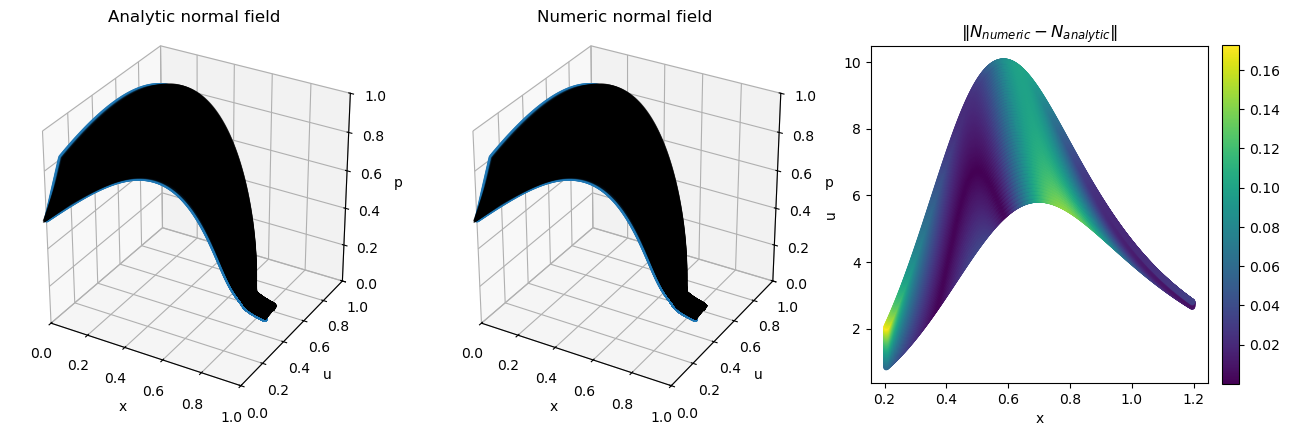

In [6]:
cmp_est = mfd.estimate_normal_field(
    X, window=normal_window, degree=normal_degree,
    discard_boundary=True, boundary_margin=normal_boundary_margin,
)
X_stacked_cmp = gtr.concatenate_trajectories(cmp_est.apply(X))
N_numeric_cmp = cmp_est.N.reshape(3, -1)
N_analytic_cmp = gtr.NORMALS[ode_args.ode](X_stacked_cmp[0], X_stacked_cmp[1])

normal_error = np.linalg.norm(N_numeric_cmp - N_analytic_cmp, axis=0)
print(
    f"||N_numeric - N_analytic||: max={np.max(normal_error):.3e}, "
    f"mean={np.mean(normal_error):.3e} (window={normal_window}, degree={normal_degree}, "
    f"boundary_margin={normal_boundary_margin}, num_points={num_points})"
)

cmp_fig = plt.figure(figsize=(13, 4.5))
ax_an = cmp_fig.add_subplot(131, projection='3d')
ax_num = cmp_fig.add_subplot(132, projection='3d')
ax_err = cmp_fig.add_subplot(133)

plot.scaled_3D_quiver(X_stacked_cmp, N_analytic_cmp, mode="normal", ax=ax_an)
ax_an.set_title("Analytic normal field")

plot.scaled_3D_quiver(X_stacked_cmp, N_numeric_cmp, mode="normal", ax=ax_num)
ax_num.set_title("Numeric normal field")

sc = ax_err.scatter(X_stacked_cmp[0], X_stacked_cmp[1], c=normal_error, cmap='viridis', s=10)
ax_err.set_xlabel("x")
ax_err.set_ylabel("u")
ax_err.set_title(r"$\|N_{numeric} - N_{analytic}\|$")
ax_err.set_box_aspect(1)
cmp_fig.colorbar(sc, ax=ax_err, fraction=0.046, pad=0.04)

cmp_fig.tight_layout()

### Convergence of the numeric normal field estimator

Sweep `num_points` (at a few `window`/`degree` choices) and track:

1. the raw normal-field estimation error `max|N_numeric - N_analytic|` (using
   `analytic_derivative=True` trajectories, so this isolates the error introduced by
   `estimate_normal_field` itself, not conflated with `u_x` derivative-estimation error), and
2. the resulting sharpness of the SV-spectrum drop when the *numeric* normal field is fed into
   `solver.solve_svd` — the normal-field analogue of the convergence cell above.

          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 30 points/trajectory       │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 100 points/trajectory      │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 300 points/trajectory      │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

...

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 1000 points/trajectory     │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 10 initial conditions      │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


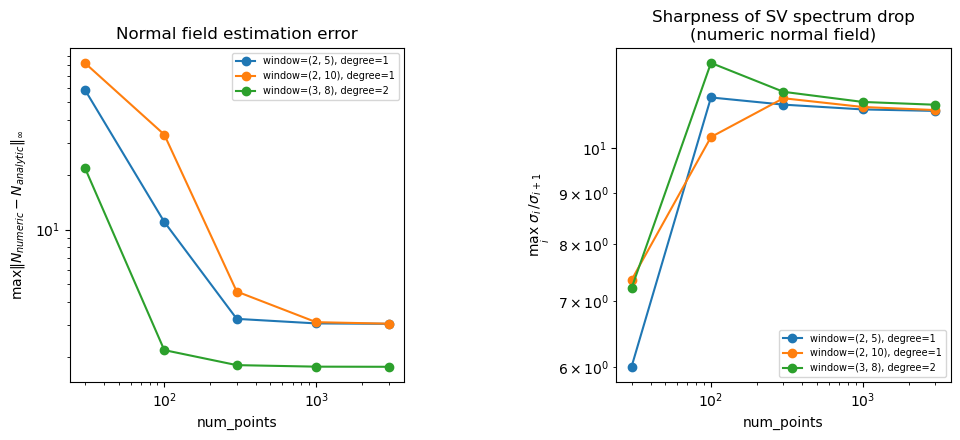

In [6]:
sweep_num_points_normal = [30, 100, 300, 1000, 3000]
window_settings = {
    f"window={normal_window}, degree={normal_degree}": (normal_window, normal_degree),
    "window=(2, 10), degree=1": ((2, 10), 1),
    "window=(3, 8), degree=2": ((3, 8), 2),
}

normal_convergence = {}
for label, (w, deg) in window_settings.items():
    max_errs, gap_ratios = [], []
    for n in sweep_num_points_normal:
        X_n = gtr.generate_equation_manifold(
            ode_name=ode_args.ode, x_start=ode_args.start, x_end=ode_args.end,
            initial_conditions=ode_args.initial_conditions, num_points=n,
            method=ode_args.method, rtol=ode_args.rtol, atol=ode_args.atol,
            analytic_derivative=True,
        )
        try:
            est_n = mfd.estimate_normal_field(X_n, window=w, degree=deg, discard_boundary=True)
        except ValueError:
            max_errs.append(np.nan)
            gap_ratios.append(np.nan)
            continue

        X_stacked_n = gtr.concatenate_trajectories(est_n.apply(X_n))
        N_numeric_n = est_n.N.reshape(3, -1)
        N_analytic_n = gtr.NORMALS[ode_args.ode](X_stacked_n[0], X_stacked_n[1])
        max_errs.append(np.max(np.abs(N_numeric_n - N_analytic_n)))

        svd_n = solver.solve_svd(
            X_stacked_n, N_numeric_n, basis_type="monomial", param_range=(0, 1), characteristic=False
        )
        Sn = svd_n.S / svd_n.S[0]
        gap_ratios.append(np.max(Sn[:-1] / Sn[1:]))

    normal_convergence[label] = (np.array(max_errs), np.array(gap_ratios))

nc_fig, (ax_nc_err, ax_nc_gap) = plt.subplots(1, 2, figsize=(11, 4.5))
for label, (max_errs, gap_ratios) in normal_convergence.items():
    ax_nc_err.loglog(sweep_num_points_normal, max_errs, marker='o', label=label)
    ax_nc_gap.loglog(sweep_num_points_normal, gap_ratios, marker='o', label=label)

ax_nc_err.set_xlabel("num_points")
ax_nc_err.set_ylabel(r"$\max\|N_{numeric} - N_{analytic}\|_\infty$")
ax_nc_err.set_title("Normal field estimation error")
ax_nc_err.legend(fontsize=7)
ax_nc_err.set_box_aspect(1)

ax_nc_gap.set_xlabel("num_points")
ax_nc_gap.set_ylabel(r"$\max_i\ \sigma_i/\sigma_{i+1}$")
ax_nc_gap.set_title("Sharpness of SV spectrum drop\n(numeric normal field)")
ax_nc_gap.legend(fontsize=7)
ax_nc_gap.set_box_aspect(1)

nc_fig.tight_layout()

## 3. Symmetry detection

(equivalent to `examples/run_odes_demo.py`)

Change `BASIS_TYPE`, `PARAM_RANGE`, or `PARAM_LIST` below and re-run from here
— the trajectories generated above are reused as-is. This first solves the
SVD; it does **not** decide which singular value(s) are "small" or which one
to reconstruct from — that's a separate, explicit choice made further down,
once you can see the results. The `characteristic` variable determines whether
we look for a characteristic or regular point symmetry.

Estimated null-space dimension: 1
Small singular value indices: [7]


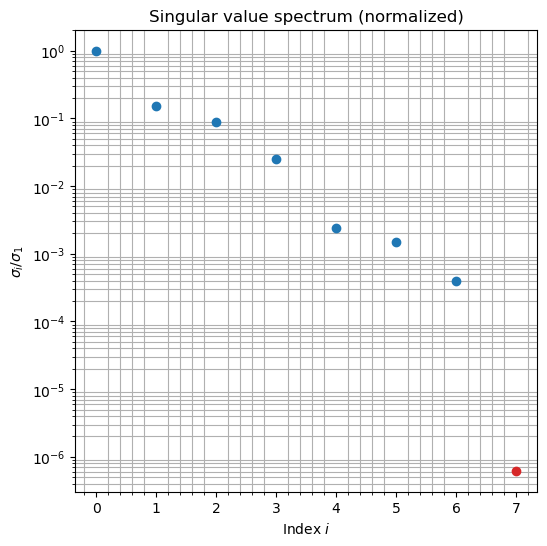

In [16]:
# --- Basis function family ---
# "monomial" or "chebyshev" (see symmetry_detection.basis_functions.BASIS_FUNCTIONS)
BASIS_TYPE = "monomial"
characteristic = False

# --- Basis elements: pick a range OR an explicit list, exactly like the CLI's
# --param_range / --param_list flags (see data_matrices.resolve_basis_args).
# PARAM_LIST always overrides PARAM_RANGE when it is not None.
PARAM_RANGE = (0, 1)  # all (m, n) pairs with m, n in 0..3
PARAM_LIST = None #[(0,0), (-2,2)] #[(0,0), (1,0), (-2,2)]    # e.g. [(0, 0), (1, 0), (0, 1), (2, 1)] to pick elements individually
sv_ratio = 1000

# Resolve basis parameters the same way the CLI does: PARAM_LIST overrides
# PARAM_RANGE, and any still-missing field falls back to symmetry_detection.defaults.
basis_args = argparse.Namespace(
    basis_type=BASIS_TYPE,
    param_range=list(PARAM_RANGE) if PARAM_RANGE is not None else None,
    param_list=PARAM_LIST,
)
basis_args = dm.resolve_basis_args(basis_args)

# Build the homogeneous system and solve its null space via SVD. This is
# pure linear algebra: solve_svd makes no judgment about which singular
# value(s) are "small" - that's a separate, explicit step below, done only
# after you can see svd_result.S here.
svd_result = solver.solve_svd(
    X_stacked, N,
    basis_type=basis_args.basis_type,
    param_range=basis_args.param_range,
    param_list=basis_args.param_list,
    characteristic=characteristic
)
small_sv_idx = solver.small_singular_value_indices(svd_result.S, drop_ratio=sv_ratio)
rpt.print_svd_summary(svd_result.S, small_sv_idx)

S_norm = svd_result.S / svd_result.S[0]
all_idx = np.arange(len(svd_result.S))
large_sv_idx = np.setdiff1d(all_idx, small_sv_idx, assume_unique=True)

fig3, ax3 = plt.subplots(figsize=(6, 6))

ax3.semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax3.semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax3.set_xlabel("Index $i$")
ax3.set_ylabel(r"$\sigma_i / \sigma_1$")
ax3.set_title("Singular value spectrum (normalized)")
ax3.set_box_aspect(1)
ax3.grid(which='minor')
ax3.minorticks_on()

### Base space infinitesimal generator

Based on the small singular value indices printed above, set `SV_CHOICE`
(0 = the largest of the small ones, up to `len(small_sv_idx) - 1` = the
globally smallest) and re-run from here. This only matters when the
estimated null space above has dimension > 1.

Selected singular value: sigma_17 = 7.267e-03 (out of 18)
Plotting point symmetry X = xi d/dx + eta d/du. Scaled by 0.5


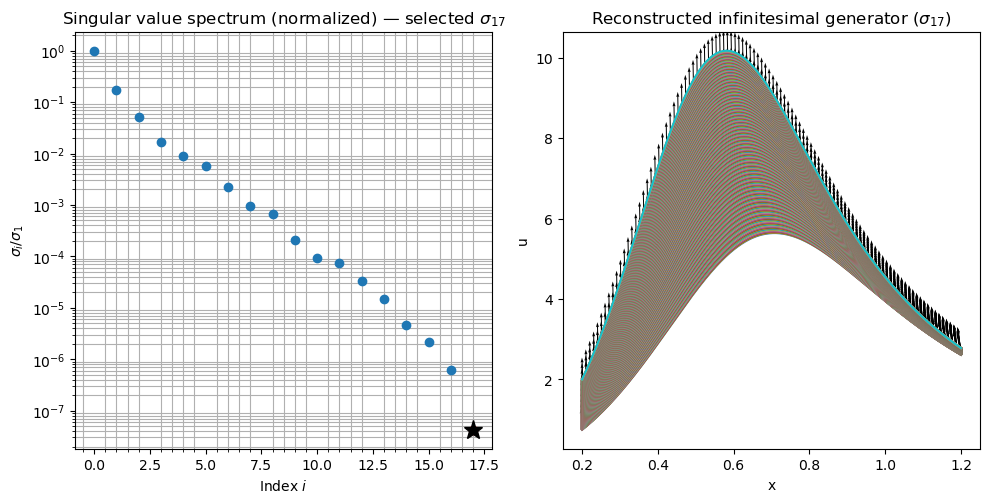

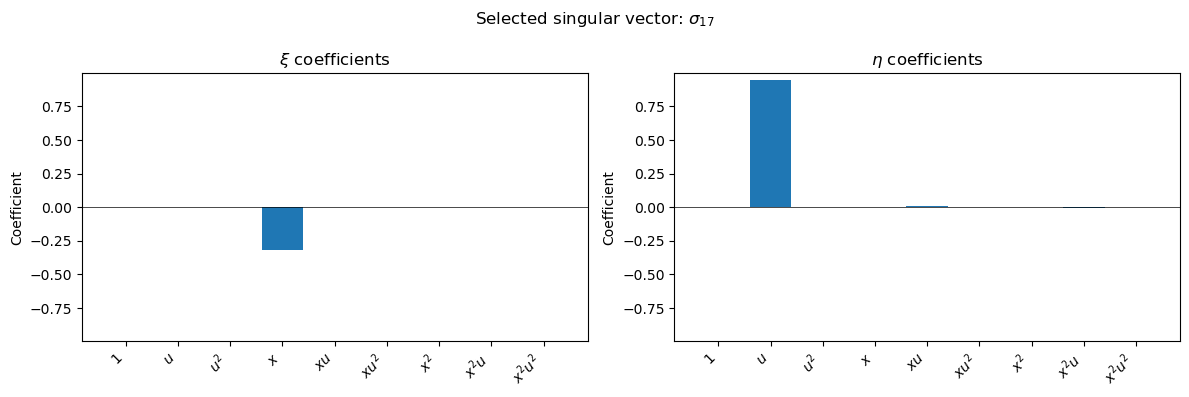

In [15]:
# Indexes into small_sv_idx, printed above (not an absolute S/Vt index).
# Out-of-range values are clamped to the nearest valid choice with a warning.
SV_CHOICE = 0
normalize_quiver = True
scale_quiver = 0.5

idx = solver.pick_small_singular_value(small_sv_idx, sv_choice=SV_CHOICE)
result = solver.select_singular_vector(svd_result, idx, characteristic=characteristic)
rpt.print_selection_summary(result.S, result.idx)

# Every plot below is derived from this one chosen singular vector.
sigma_label = rf"$\sigma_{{{result.idx}}}$"

# Same spectrum as above (fig3/ax3), on a new axis, with the chosen
# singular value starred.
fig4, ax4 = plt.subplots(1,2, figsize=(10, 6))

ax4[0].semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax4[0].semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax4[0].semilogy(result.idx, S_norm[result.idx], marker='*', markersize=14, linestyle='None', color='k', zorder=3)
ax4[0].set_xlabel("Index $i$")
ax4[0].set_ylabel(r"$\sigma_i / \sigma_1$")
ax4[0].set_title(f"Singular value spectrum (normalized) \u2014 selected {sigma_label}")
ax4[0].set_box_aspect(1)
ax4[0].grid(which='minor')
ax4[0].minorticks_on()

if normalize_quiver:
    xy_norm = np.sqrt(result.xi**2 + result.eta**2)
    xy_norm[xy_norm == 0] = 1
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi / xy_norm, result.eta / xy_norm, angles='uv', scale=20)
elif scale_quiver < 1:
    ax4[1].quiver(X_stacked[0], X_stacked[1], scale_quiver*result.xi, scale_quiver*result.eta, angles='uv', scale=20)
else:
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi, result.eta, angles='xy', scale=20, scale_units='xy')

for trajectory in X:
    ax4[1].plot(trajectory[0], trajectory[1])
ax4[1].set_xlabel("x")
ax4[1].set_ylabel("u")
ax4[1].set_title(f"Reconstructed infinitesimal generator ($\\sigma_{{{result.idx}}}$)")
ax4[1].set_box_aspect(1)

fig4.tight_layout()

# Coefficients
n_basis = len(result.param_list)

bars_fig, (ax_xi, ax_eta) = plt.subplots(1, 2, figsize=(12, 4))
bars_fig.suptitle(f"Selected singular vector: {sigma_label}")
coeff_ylim = plot.shared_coefficient_ylim(result.singular_vector[:n_basis], result.singular_vector[n_basis:])
plot.plot_basis_coefficient_bars(
    result.singular_vector[:n_basis], result.param_list, basis_args.basis_type,
    ax=ax_xi, title=r"$\xi$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
plot.plot_basis_coefficient_bars(
    result.singular_vector[n_basis:], result.param_list, basis_args.basis_type,
    ax=ax_eta, title=r"$\eta$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
bars_fig.tight_layout()

if characteristic:
    print(f"Plotting characteristic point symmetry Xhat = Q d/du, with Q = eta - u_x * xi. Scaled by {scale_quiver}")
else:
    print(f"Plotting point symmetry X = xi d/dx + eta d/du. Scaled by {scale_quiver}")

### Jet-space infinitesimal generator

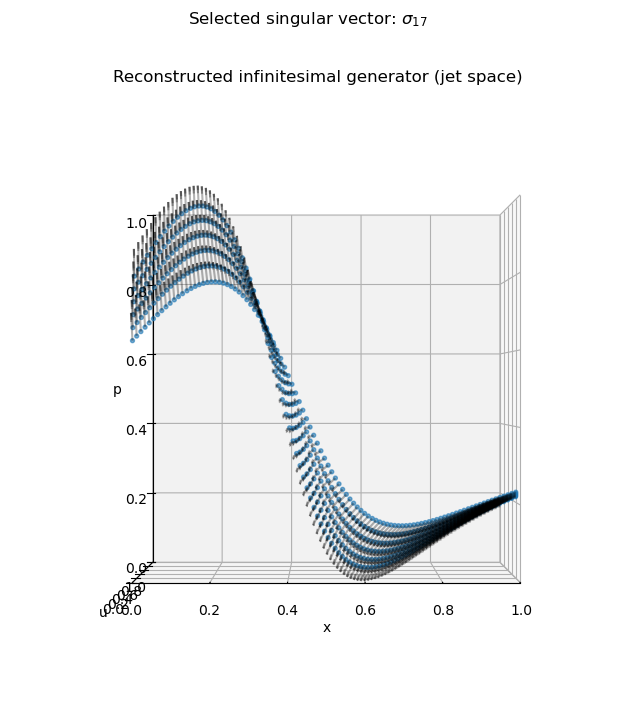

In [9]:
V = np.stack((result.xi, result.eta, result.zeta))

jet_fig, jet_ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(8, 8))
jet_fig.suptitle(f"Selected singular vector: {sigma_label}")
plot.scaled_3D_quiver(X_stacked, V, mode="tangent", ax=jet_ax)
jet_ax.set_title("Reconstructed infinitesimal generator (jet space)")
jet_ax.view_init(elev=0, azim=270, roll=0)
